In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

PASTA_DADOS = Path('dados_tratados')
META_ANUAL = 88000
META_COLABORATIVA = 70000

#   confirmar de onde vem o valor real de engajamento com o MEJ?
#   idem para "Tempo de Permanência no MEJ" e "Políticas de Diversidade e Inclusão"
ENG_MEJ_PCT_ASSUMIDO = 0.70          # 0.70 = 70% de engajamento (valor ilustrativo, igual ao exemplo do PDF)
CLUSTER_ANTERIOR_CONHECIDO = None    # cluster oficial do ano anterior — preencher se a Direx informar
SELO_EJ_EM_CONFORMIDADE = True       # confirmar com o gestor antes da entrega final

In [13]:
def carregar_bases(pasta=PASTA_DADOS):
    '''Carrega as saídas dos notebooks anteriores. Nenhuma delas precisa ser reexecutada
    para rodar este notebook — todas já existem em `dados_tratados/`.'''
    base_mensal = pd.read_csv(pasta / 'base_cluster_mensal.csv')
    projetos = pd.read_csv(pasta / 'projetos_tratados.csv', parse_dates=['data_inicio', 'data_fim', 'data_registro'])
    previsao = pd.read_csv(pasta / 'previsao_faturamento.csv')
    with open(pasta / 'trajetoria_metas.json', encoding='utf-8') as f:
        trajetoria_metas = json.load(f)
    return base_mensal, projetos, previsao, trajetoria_metas

base_mensal, projetos, previsao, trajetoria_metas = carregar_bases()
projetos[['nome_projeto', 'ano_inicio', 'status', 'satisfacao', 'valor_total_projeto', 'projeto_de_impacto']].tail()

,nome_projeto,ano_inicio,status,satisfacao,valor_total_projeto,projeto_de_impacto
14,Projeto Aurora II,2025,Concluído,4.0,7000,False
15,Projeto Diavicon,2026,Em andamento,NaN,25000,True
16,Projeto JMorais,2026,Em andamento,NaN,5500,False
17,Projeto Arthur,2026,Concluído,NaN,0,False
18,Projeto Plutão,2026,Iniciado,NaN,33823,False


In [14]:
REGUA_CLUSTER = [
    (0,             12_000_000,   1),
    (12_000_000.01, 24_000_000,   2),
    (24_000_000.01, 61_000_000,   3),
    (61_000_000.01, 130_000_000,  4),
    (130_000_000.01, float('inf'), 5),
]

def classificar_cluster(indice):
    '''Mapeia um índice numérico para o cluster (1 a 5) conforme a régua oficial.'''
    for minimo, maximo, cluster in REGUA_CLUSTER:
        if minimo <= indice <= maximo:
            return cluster
    return None

pd.DataFrame(REGUA_CLUSTER, columns=['minimo', 'maximo', 'cluster'])

,minimo,maximo,cluster
0,0.000000e+00,12000000.0,1
1,1.200000e+07,24000000.0,2
2,2.400000e+07,61000000.0,3
3,6.100000e+07,130000000.0,4
4,1.300000e+08,inf,5


In [15]:
def calcular_indice_cluster(faturamento, csat, eng_mej_pct, pct_faturamento_colaborativo):
    '''
    Índice = Faturamento x CSAT x (1 + %Engajamento MEJ) x (1 + %Faturamento Colaborativo) x 100
    (fórmula tirada literalmente da Calculadora de Cluster do PDF do projeto).
    '''
    pct_faturamento_colaborativo = 0 if pd.isna(pct_faturamento_colaborativo) else pct_faturamento_colaborativo
    eng_mej_pct = 0 if pd.isna(eng_mej_pct) else eng_mej_pct
    csat = 0 if pd.isna(csat) else csat
    return faturamento * csat * (1 + eng_mej_pct) * (1 + pct_faturamento_colaborativo) * 100

# Validação com o exemplo do próprio PDF: Faturamento R$ 88.000, CSAT 5, Eng.MEJ 1.70, Fat.Colab 1.80
indice_exemplo = calcular_indice_cluster(88000, 5, 0.70, 0.80)
print(f'Índice de exemplo: {indice_exemplo:,.0f}  →  cluster {classificar_cluster(indice_exemplo)}')
print('Esperado no PDF: 134.300.000,00 (a pequena diferença é arredondamento do próprio exemplo)')

Índice de exemplo: 134,640,000  →  cluster 5
Esperado no PDF: 134.300.000,00 (a pequena diferença é arredondamento do próprio exemplo)


In [16]:
def aplicar_regras_cluster(cluster_bruto, faturamento_ano, qtd_projetos_impacto_ano,
                            cluster_anterior=None, selo_ej_ok=True):
    '''
    Aplica, em ordem, as 4 restrições do PDF:
      1) Fechou o ano com faturamento = 0        -> rebaixada automaticamente para o Cluster 1.
      2) Cluster bruto = 5 sem projeto de impacto -> trava em 4 (Cluster 5 exige projeto de impacto).
      3) Fora de conformidade com o Selo EJ       -> não sobe cluster nenhum.
      4) Só é permitido subir 1 (um) cluster por vez, por ano.
    Retorna (cluster_final, lista_de_motivos_que_alteraram_o_resultado).
    '''
    if faturamento_ano <= 0:
        return 1, ['faturamento_zero_no_ano']

    cluster_final = cluster_bruto
    motivos = []

    if cluster_bruto == 5 and qtd_projetos_impacto_ano < 1:
        cluster_final = 4
        motivos.append('sem_projeto_de_impacto_trava_cluster_5')

    if cluster_anterior is not None:
        if not selo_ej_ok and cluster_final > cluster_anterior:
            cluster_final = cluster_anterior
            motivos.append('selo_ej_fora_de_conformidade')
        elif cluster_final > cluster_anterior + 1:
            cluster_final = cluster_anterior + 1
            motivos.append('subida_limitada_a_1_cluster_por_ano')

    return cluster_final, motivos

In [17]:
projetos['ano'] = projetos['ano_inicio']

resumo_anual = projetos.groupby('ano').agg(
    faturamento_total=('valor_total_projeto', 'sum'),
    faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
    qtd_projetos_impacto=('projeto_de_impacto', 'sum'),
    csat_medio=('satisfacao', 'mean'),
).reset_index()
resumo_anual['pct_faturamento_colaborativo'] = (
    resumo_anual['faturamento_colaborativo'] / resumo_anual['faturamento_total']
)

# Anos/meses sem avaliação de CSAT concluída usam a média histórica geral como aproximação
# (ex.: 2026 — todos os projetos do ano ainda estão "Em andamento"/"Iniciado", sem CSAT coletado).
CSAT_HISTORICO_GERAL = projetos['satisfacao'].mean()
print(f'CSAT histórico geral (fallback p/ anos sem avaliação concluída): {CSAT_HISTORICO_GERAL:.2f}')

def avaliar_ano(row, eng_mej_pct=ENG_MEJ_PCT_ASSUMIDO, cluster_anterior=None,
                 selo_ej_ok=True, csat_fallback=CSAT_HISTORICO_GERAL):
    csat_usado = row['csat_medio'] if pd.notna(row['csat_medio']) else csat_fallback
    indice = calcular_indice_cluster(row['faturamento_total'], csat_usado, eng_mej_pct,
                                      row['pct_faturamento_colaborativo'])
    cluster_bruto = classificar_cluster(indice)
    cluster_final, motivos = aplicar_regras_cluster(
        cluster_bruto, row['faturamento_total'], row['qtd_projetos_impacto'], cluster_anterior, selo_ej_ok
    )
    return pd.Series({
        'csat_usado': csat_usado,
        'indice_cluster': indice,
        'cluster_bruto': cluster_bruto,
        'cluster_final': cluster_final,
        'motivos_ajuste': ', '.join(motivos) if motivos else None,
    })

avaliacao_hist = resumo_anual.join(resumo_anual.apply(avaliar_ano, axis=1))
avaliacao_hist

CSAT histórico geral (fallback p/ anos sem avaliação concluída): 4.60


,ano,faturamento_total,faturamento_colaborativo,qtd_projetos_impacto,csat_medio,pct_faturamento_colaborativo,csat_usado,indice_cluster,cluster_bruto,cluster_final,motivos_ajuste
0,2024,114500,60000,1,4.555556,0.524017,4.555556,1.351406e+08,5.0,5.0,NaN
1,2025,88000,60000,1,4.666667,0.681818,4.666667,1.174133e+08,4.0,4.0,NaN
2,2026,64323,0,1,NaN,0.000000,4.600000,5.030059e+07,3.0,3.0,NaN


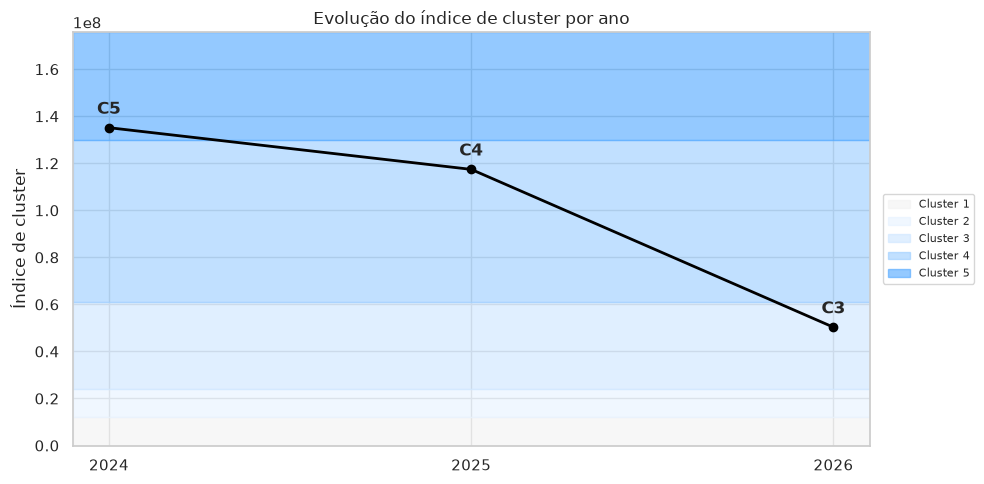

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

cores_faixa = ['#f2f2f2', '#e6f2ff', '#cce5ff', '#99ccff', '#4da6ff']
limite_visual = max(avaliacao_hist['indice_cluster'].max() * 1.3, 20_000_000)
for (minimo, maximo, cluster), cor in zip(REGUA_CLUSTER, cores_faixa):
    topo = min(maximo, limite_visual)
    ax.axhspan(minimo, topo, color=cor, alpha=0.6, label=f'Cluster {cluster}')

ax.plot(avaliacao_hist['ano'].astype(str), avaliacao_hist['indice_cluster'],
        marker='o', color='black', linewidth=2, zorder=5)
for _, row in avaliacao_hist.iterrows():
    ax.annotate(f"C{int(row['cluster_final'])}", (str(int(row['ano'])), row['indice_cluster']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

ax.set_ylim(0, limite_visual)
ax.set_ylabel('Índice de cluster')
ax.set_title('Evolução do índice de cluster por ano')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
traj_total = trajetoria_metas['faturamento_total']
traj_colab = trajetoria_metas['faturamento_colaborativo']

faturamento_projetado = traj_total['total_projetado_ano']
colaborativo_projetado = traj_colab['total_projetado_ano']
pct_colaborativo_projetado = colaborativo_projetado / faturamento_projetado

ano_referencia = traj_total['ano_referencia']
qtd_impacto_ano = int(resumo_anual.loc[resumo_anual['ano'] == ano_referencia, 'qtd_projetos_impacto'].iloc[0])

def avaliar_cenario(faturamento, csat, eng_mej_pct, pct_colab, qtd_impacto,
                     cluster_anterior=CLUSTER_ANTERIOR_CONHECIDO, selo_ej_ok=SELO_EJ_EM_CONFORMIDADE):
    indice = calcular_indice_cluster(faturamento, csat, eng_mej_pct, pct_colab)
    cluster_bruto = classificar_cluster(indice)
    cluster_final, motivos = aplicar_regras_cluster(cluster_bruto, faturamento, qtd_impacto, cluster_anterior, selo_ej_ok)
    return {
        'faturamento': faturamento, 'csat': csat, 'eng_mej_pct': eng_mej_pct,
        'pct_faturamento_colaborativo': pct_colab, 'qtd_projetos_impacto': qtd_impacto,
        'indice_cluster': indice, 'cluster_bruto': cluster_bruto,
        'cluster_final': cluster_final, 'motivos_ajuste': ', '.join(motivos) if motivos else None,
    }

avaliacao_projetada = avaliar_cenario(
    faturamento_projetado, CSAT_HISTORICO_GERAL, ENG_MEJ_PCT_ASSUMIDO,
    pct_colaborativo_projetado, qtd_impacto_ano
)

print(f"Ano de referência: {ano_referencia}")
print(f"Faturamento projetado (fim de ano): R$ {faturamento_projetado:,.2f}")
print(f"% faturamento colaborativo projetado: {pct_colaborativo_projetado:.1%}")
print(f"Projetos de impacto no ano: {qtd_impacto_ano}")
print(f"Índice de cluster projetado: {avaliacao_projetada['indice_cluster']:,.0f}")
print(f"Cluster projetado (bruto): {avaliacao_projetada['cluster_bruto']}")
print(f"Cluster projetado (final, após regras): {avaliacao_projetada['cluster_final']}")
if avaliacao_projetada['motivos_ajuste']:
    print(f"Motivos do ajuste: {avaliacao_projetada['motivos_ajuste']}")

Ano de referência: 2026
Faturamento projetado (fim de ano): R$ 103,264.76
% faturamento colaborativo projetado: 0.0%
Projetos de impacto no ano: 1
Índice de cluster projetado: 80,753,039
Cluster projetado (bruto): 4
Cluster projetado (final, após regras): 4


In [20]:
cenarios_engajamento = {
    'pessimista (40%)': 0.40,
    'assumido no notebook (70%)': ENG_MEJ_PCT_ASSUMIDO,
    'meta institucional (75%)': 0.75,
    'otimista (90%)': 0.90,
}

linhas_sensibilidade = []
for rotulo, valor in cenarios_engajamento.items():
    resultado = avaliar_cenario(faturamento_projetado, CSAT_HISTORICO_GERAL, valor,
                                 pct_colaborativo_projetado, qtd_impacto_ano)
    linhas_sensibilidade.append({'cenario_engajamento_mej': rotulo, 'eng_mej_pct': valor,
                                  'indice_cluster': resultado['indice_cluster'],
                                  'cluster_final': resultado['cluster_final']})

sensibilidade_eng_mej = pd.DataFrame(linhas_sensibilidade)
sensibilidade_eng_mej

,cenario_engajamento_mej,eng_mej_pct,indice_cluster,cluster_final
0,pessimista (40%),0.40,6.650250e+07,4
1,assumido no notebook (70%),0.70,8.075304e+07,4
2,meta institucional (75%),0.75,8.312813e+07,4
3,otimista (90%),0.90,9.025340e+07,4


In [ ]:
def gerar_recomendacoes(avaliacao, meta_cluster=5):
    recomendacoes = []
    if avaliacao['cluster_final'] >= meta_cluster:
        recomendacoes.append('Trajetória projetada já atinge o Cluster 5 — foco em manter faturamento e projeto de impacto.')
        return recomendacoes

    limite_inferior_meta = next(minimo for minimo, maximo, c in REGUA_CLUSTER if c == meta_cluster)
    fator_atual = avaliacao['csat'] * (1 + avaliacao['eng_mej_pct']) * (1 + avaliacao['pct_faturamento_colaborativo']) * 100
    faturamento_necessario = limite_inferior_meta / fator_atual if fator_atual > 0 else float('inf')
    gap_faturamento = faturamento_necessario - avaliacao['faturamento']

    if gap_faturamento > 0:
        recomendacoes.append(
            f'Mantendo CSAT, engajamento e % colaborativo atuais, seria necessário faturar cerca de '
            f'R$ {faturamento_necessario:,.0f} no ano (gap de R$ {gap_faturamento:,.0f}) para alcançar o Cluster 5.'
        )
    if avaliacao['qtd_projetos_impacto'] < 1:
        recomendacoes.append('Nenhum projeto de impacto registrado no ano — condição obrigatória para o Cluster 5.')
    return recomendacoes

for recomendacao in gerar_recomendacoes(avaliacao_projetada):
    print('•', recomendacao)

In [ ]:
def exportar_avaliacao_cluster(avaliacao_hist, avaliacao_projetada, sensibilidade, pasta=PASTA_DADOS):
    pasta = Path(pasta)
    pasta.mkdir(exist_ok=True)

    avaliacao_hist.to_csv(pasta / 'avaliacao_cluster_historico.csv', index=False)
    sensibilidade.to_csv(pasta / 'sensibilidade_engajamento_mej.csv', index=False)

    saida = {
        'ano_referencia': int(ano_referencia),
        'parametros_assumidos': {
            'eng_mej_pct': ENG_MEJ_PCT_ASSUMIDO,
            'csat_fallback_historico': float(CSAT_HISTORICO_GERAL),
            'cluster_anterior_conhecido': CLUSTER_ANTERIOR_CONHECIDO,
            'selo_ej_em_conformidade': SELO_EJ_EM_CONFORMIDADE,
            'observacao': (
                'eng_mej_pct, tempo de permanencia no MEJ e politicas de diversidade e inclusao '
                'ainda precisam ser confirmados com o gestor — nao vem do formulario de projetos.'
            ),
        },
        'avaliacao_projetada': avaliacao_projetada,
    }
    with open(pasta / 'avaliacao_cluster_projetada.json', 'w', encoding='utf-8') as f:
        json.dump(saida, f, ensure_ascii=False, indent=2)

    print('Arquivos salvos em', pasta.resolve())
    print(' - avaliacao_cluster_historico.csv')
    print(' - sensibilidade_engajamento_mej.csv')
    print(' - avaliacao_cluster_projetada.json')

exportar_avaliacao_cluster(avaliacao_hist, avaliacao_projetada, sensibilidade_eng_mej)

In [ ]:
def executar_avaliacao_cluster(pasta_dados=PASTA_DADOS, eng_mej_pct=ENG_MEJ_PCT_ASSUMIDO,
                                cluster_anterior=CLUSTER_ANTERIOR_CONHECIDO,
                                selo_ej_ok=SELO_EJ_EM_CONFORMIDADE):
    print('Iniciando avaliação de cluster...\n')

    base_mensal, projetos, previsao, trajetoria_metas = carregar_bases(pasta_dados)
    projetos['ano'] = projetos['ano_inicio']

    resumo = projetos.groupby('ano').agg(
        faturamento_total=('valor_total_projeto', 'sum'),
        faturamento_colaborativo=('valor_faturamento_colaborativo', 'sum'),
        qtd_projetos_impacto=('projeto_de_impacto', 'sum'),
        csat_medio=('satisfacao', 'mean'),
    ).reset_index()
    resumo['pct_faturamento_colaborativo'] = resumo['faturamento_colaborativo'] / resumo['faturamento_total']
    csat_fallback = projetos['satisfacao'].mean()

    avaliacao = resumo.join(resumo.apply(
        lambda row: avaliar_ano(row, eng_mej_pct, cluster_anterior, selo_ej_ok, csat_fallback), axis=1
    ))

    traj_total = trajetoria_metas['faturamento_total']
    traj_colab = trajetoria_metas['faturamento_colaborativo']
    faturamento_proj = traj_total['total_projetado_ano']
    pct_colab_proj = traj_colab['total_projetado_ano'] / faturamento_proj
    ano_ref = traj_total['ano_referencia']
    qtd_impacto = int(resumo.loc[resumo['ano'] == ano_ref, 'qtd_projetos_impacto'].iloc[0])

    projetada = avaliar_cenario(faturamento_proj, csat_fallback, eng_mej_pct, pct_colab_proj,
                                 qtd_impacto, cluster_anterior, selo_ej_ok)

    print(f"Cluster final projetado para {ano_ref}: {projetada['cluster_final']}")
    print('Avaliação concluída com sucesso.')

    return {'avaliacao_historico': avaliacao, 'avaliacao_projetada': projetada}

# Execução única, de ponta a ponta — usar esta célula para reprocessar tudo de uma vez
resultado_final = executar_avaliacao_cluster()